In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
medSAM_MnM= torch.load("medSAM_MnM")
DINOv2_MnM= torch.load("DINOv2_MnM")

medSAM_MnM_ood= torch.load("medSAM_MnM_ood")
DINOv2_MnM_ood= torch.load("DINOv2_MnM_ood")

print(medSAM_MnM.shape)
print(DINOv2_MnM.shape)
print(medSAM_MnM_ood.shape)
print(DINOv2_MnM_ood.shape)

torch.Size([750, 256])
torch.Size([525, 768])
torch.Size([450, 256])
torch.Size([450, 768])


In [4]:
cov_medSAM=torch.cov(medSAM_MnM.T)
cov_DINOv2=torch.cov(DINOv2_MnM.T)

eigvals_medSAM = torch.linalg.eigvalsh(cov_medSAM)
eigvals_DINOv2 = torch.linalg.eigvalsh(cov_DINOv2)

eigvals_medSAM = torch.sort(eigvals_medSAM, descending=True).values
eigvals_DINOv2 = torch.sort(eigvals_DINOv2, descending=True).values

In [17]:
print((eigvals_medSAM < 1e-10).sum())

tensor(21)


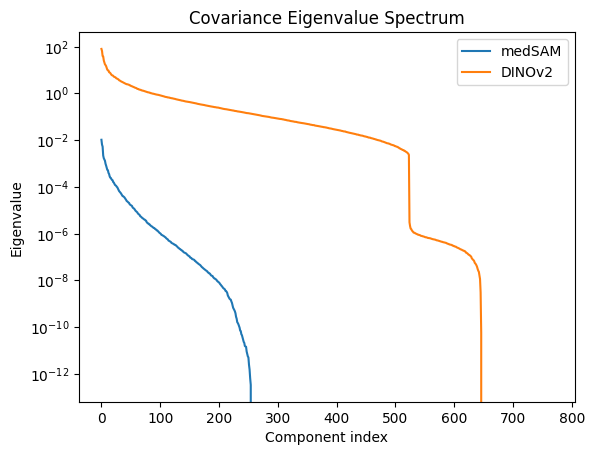

In [10]:
import matplotlib.pyplot as plt
import torch

# Sort eigenvalues first
eigvals_medSAM = torch.sort(eigvals_medSAM, descending=True).values
eigvals_DINOv2 = torch.sort(eigvals_DINOv2, descending=True).values

# Plot both
plt.plot(eigvals_medSAM.cpu().numpy(), label="medSAM")
plt.plot(eigvals_DINOv2.cpu().numpy(), label="DINOv2")

plt.title("Covariance Eigenvalue Spectrum")
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.yscale("log")  # very useful!
plt.legend()       # <-- this is key

plt.show()

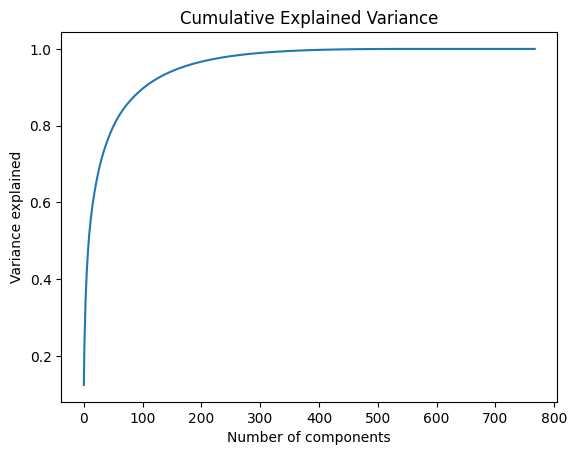

In [18]:
cumvar = eigvals_DINOv2.cumsum(0) / eigvals_DINOv2.sum()

plt.plot(cumvar.cpu().numpy())
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Variance explained")
plt.show()

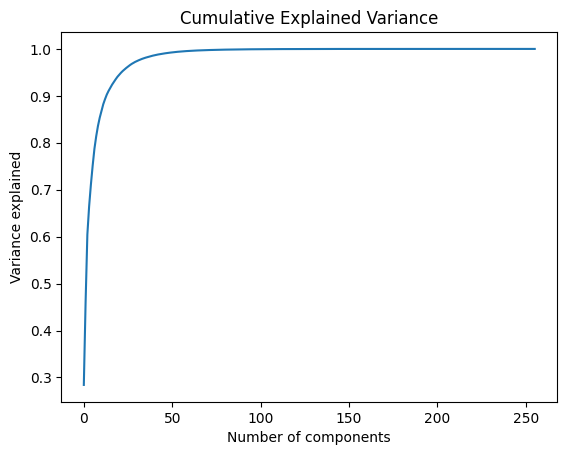

In [19]:
cumvar = eigvals_medSAM.cumsum(0) / eigvals_medSAM.sum()

plt.plot(cumvar.cpu().numpy())
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Variance explained")
plt.show()

In [13]:
def proj(cov_matrix,z_id,z_ood):
    
    eigvals, eigvecs = torch.linalg.eigh(cov_matrix)
    Z_id_centered = z_id - z_id.mean(0)
    Z_ood_centered = z_ood - z_id.mean(0)
    
    proj_id = Z_id_centered @ eigvecs
    proj_ood = Z_ood_centered @ eigvecs

    var_id = proj_id.var(dim=0)
    var_ood = proj_ood.var(dim=0)
    
    return var_id, var_ood, eigvals
    
    
    

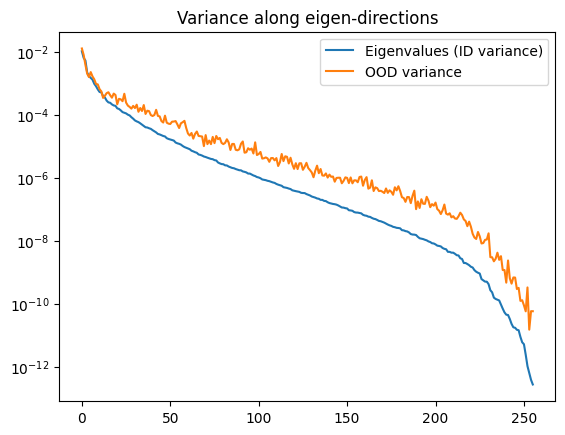

In [14]:
var_id_medSAM,var_ood_medSAM,eigvals_medSAM=proj(cov_medSAM, medSAM_MnM, medSAM_MnM_ood)



idx = torch.argsort(eigvals_medSAM, descending=True)

eigvals_sorted = eigvals_medSAM[idx]
var_id_sorted = var_id_medSAM[idx]
var_ood_sorted = var_ood_medSAM[idx]

plt.plot(eigvals_sorted.cpu(), label="Eigenvalues (ID variance)")
plt.plot(var_ood_sorted.cpu(), label="OOD variance")
plt.yscale("log")
plt.legend()
plt.title("Variance along eigen-directions")
plt.show()

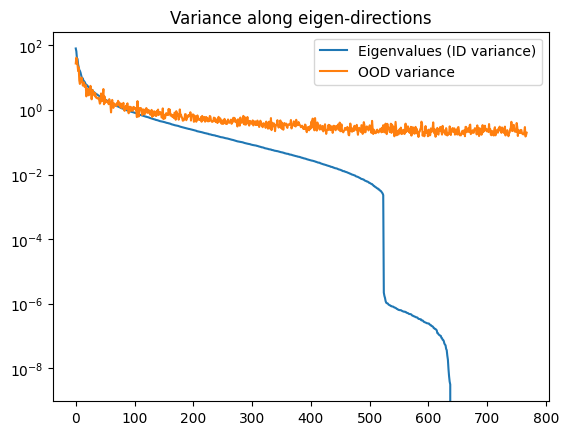

In [15]:
var_id_DINOv2,var_ood_DINOv2,eigvals_DINOv2=proj(cov_DINOv2, DINOv2_MnM, DINOv2_MnM_ood)


idx = torch.argsort(eigvals_DINOv2, descending=True)

eigvals_sorted = eigvals_DINOv2[idx]
var_id_sorted = var_id_DINOv2[idx]
var_ood_sorted = var_ood_DINOv2[idx]

plt.plot(eigvals_sorted.cpu(), label="Eigenvalues (ID variance)")
plt.plot(var_ood_sorted.cpu(), label="OOD variance")
plt.yscale("log")
plt.legend()
plt.title("Variance along eigen-directions")
plt.show()